### Q1 Supervised Learning
1. Data Loading and Inspection

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def print_summary(df: pd.DataFrame) -> None:
    """
    Print a clean summary of the dataset including:
    - Shape (rows, columns)
    - Data types of each column
    - Missing value counts
    - First five rows
    """
    print("=== Dataset Overview ===")
    print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
    
    print("\n=== Data Types ===")
    print(df.dtypes)
    
    print("\n=== Missing Values ===")
    print(df.isnull().sum())
    
    print("\n=== First Five Rows ===")
    print(df.head())

# Load the dataset and print the summary:
df = pd.read_csv("../data/q1_heart_disease.csv")
print_summary(df)

=== Dataset Overview ===
Rows: 800   Columns: 12

=== Data Types ===
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

=== Missing Values ===
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

=== First Five Rows ===
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0       

2. Exploratory Data Analysis

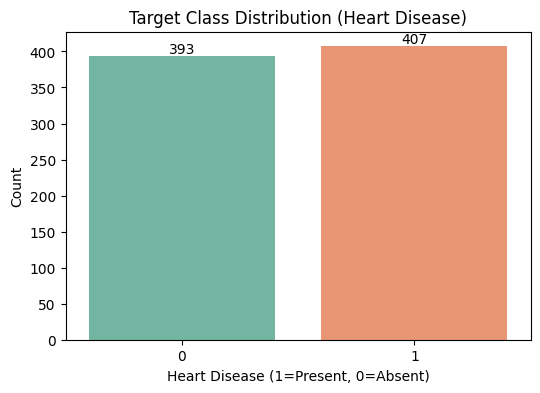

In [10]:
# Target Class Distribution with counts
plt.figure(figsize=(6,4))
ax = sns.countplot(x="heart_disease", hue="heart_disease", data=df, palette="Set2", legend=False)
plt.title("Target Class Distribution (Heart Disease)")
plt.xlabel("Heart Disease (1=Present, 0=Absent)")
plt.ylabel("Count")

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.show()


### Target Class Distribution
Shows counts of patients with and without heart disease; a taller bar for one class indicates **class imbalance**, which causes models to favor the majority class.

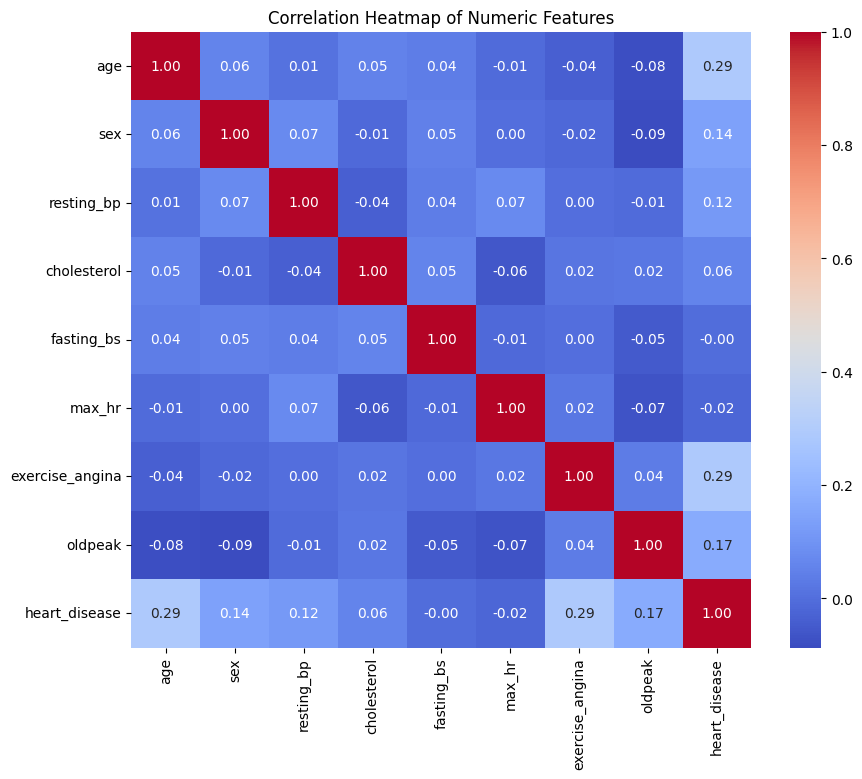

In [11]:
# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


### Correlation Heatmap
The heatmap displays Pearson correlations among numeric features and with **heart_disease**. **Age**, **oldpeak**, and **resting_bp** show the strongest positive linear relationships with the target, indicating higher values are associated with disease presence. **Max_hr** is negatively correlated, indicating lower exercise capacity relates to disease. **Cholesterol** shows little linear association. Several feature pairs show moderate inter‑correlation, suggesting potential multicollinearity (Need to check before modeling).

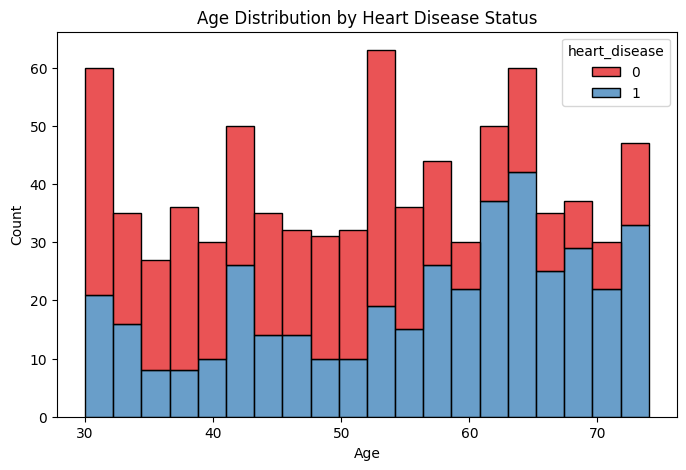

In [12]:
# 3. Age Distribution by Heart Disease
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="heart_disease", multiple="stack", bins=20, palette="Set1")
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Age Distribution by Heart Disease
Compares age distributions for heart_disease = 1 and heart_disease = 0; a rightward shift for heart_disease = 1 indicates age is positively associated with disease risk (**indicates older patients have higher disease prevalence**).

3. Data Preprocessing 
### Strategy
- **Train/test split**: `train_test_split(..., stratify=y, random_state=42)` — split first to avoid leakage.
- **Target**: **heart_disease** — no missing values.  
- **Missing values**: **resting_bp**, **cholesterol** → **median imputation** (medians learned from training set).  
- **Categorical missing**: **mode imputation** (most frequent value).  
- **Encoding**: **One‑hot encode** all categorical variables.  
- **Scaling**: **StandardScaler** on numeric features after imputation. 


In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Print initial missing-value counts for the two columns of interest
print("Missing values before:")
print(df[["resting_bp", "cholesterol"]].isnull().sum())

# -------------------------
# Separate features and target
# -------------------------

y = df["heart_disease"].astype(int)
X = df.drop(columns=["heart_disease"])

# -------------------------
# Column type detection (future-proof)
# -------------------------

cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

# Detect integer-coded categorical-like numeric columns (low cardinality)
low_cardinality_numeric = [c for c in num_cols if X[c].nunique() <= 10 and X[c].dtype.kind in ("i", "u")]
if low_cardinality_numeric:
    num_cols = [c for c in num_cols if c not in low_cardinality_numeric]
    cat_cols = list(dict.fromkeys(cat_cols + low_cardinality_numeric))

print(f"\nCategorical columns detected: {cat_cols}")
print(f"Numeric columns detected: {num_cols}")

# -------------------------
# Train/test split (prevent leakage)
# -------------------------

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# Build preprocessing pipelines
# -------------------------

# Numeric pipeline: median impute + scale
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline: mode impute + one-hot encode
# Use sparse_output=False for newer sklearn versions
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer: apply numeric pipeline to numeric cols, categorical pipeline to categorical cols
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
], remainder="drop")

# -------------------------
# Fit on training data and transform
# -------------------------

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Report missing in raw training data (before imputation)
print("\nMissing values in training raw (before imputation):")
print(X_train_raw[["resting_bp", "cholesterol"]].isnull().sum())

# -------------------------
# Print medians used for imputation (from training set)
# -------------------------

num_imputer = preprocessor.named_transformers_["num"].named_steps["imputer"]
if len(num_cols) > 0:
    medians_used = dict(zip(num_cols, num_imputer.statistics_))
else:
    medians_used = {}
print("\nMedians used for numeric imputation (learned from training set):")
print(medians_used)

# -------------------------
# Confirm no NaNs in transformed arrays
# -------------------------

print("\nNaN counts in transformed arrays:")
print("X_train NaNs:", np.isnan(X_train).sum())
print("X_test NaNs: ", np.isnan(X_test).sum())

# -------------------------
# Show class balance and other diagnostics
# -------------------------
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\ny_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

Missing values before:
resting_bp     24
cholesterol    32
dtype: int64

Categorical columns detected: ['chest_pain_type', 'resting_ecg', 'st_slope', 'sex', 'fasting_bs', 'exercise_angina']
Numeric columns detected: ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

Missing values in training raw (before imputation):
resting_bp     22
cholesterol    29
dtype: int64

Medians used for numeric imputation (learned from training set):
{'age': np.float64(53.0), 'resting_bp': np.float64(130.0), 'cholesterol': np.float64(248.0), 'max_hr': np.float64(149.0), 'oldpeak': np.float64(0.7)}

NaN counts in transformed arrays:
X_train NaNs: 0
X_test NaNs:  0

X_train shape: (640, 21)
X_test shape:  (160, 21)

y_train distribution:
heart_disease
1    326
0    314
Name: count, dtype: int64

y_test distribution:
heart_disease
1    81
0    79
Name: count, dtype: int64


4. Model Training

In [14]:
# 4. Model Training — train three classifiers with random_state=42
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Ensure preprocessing outputs exist
try:
    X_train.shape, y_train.shape
except NameError:
    raise RuntimeError("X_train and y_train are not defined. Run the preprocessing cell first.")

# Instantiate models (random_state fixed for reproducibility)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Fit models and keep them in memory
fitted_models = {}
for name, model in models.items():
    print(f"Fitting {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model

print("All models trained and stored in `fitted_models`.")


Fitting Decision Tree...
Fitting Random Forest...
Fitting Gradient Boosting...
All models trained and stored in `fitted_models`.


5. Model Evaluation 

Sorted by Weighted F1 (higher is better):

=== Model comparison (sorted by Weighted F1) ===
            Model Accuracy Macro F1 Weighted F1 Pos Precision Pos Recall Pos F1 Pos Support
    Random Forest   0.8063   0.8062      0.8062        0.8205     0.7901 0.8050          81
Gradient Boosting   0.7688   0.7687      0.7687        0.7683     0.7778 0.7730          81
    Decision Tree   0.7188   0.7187      0.7187        0.7195     0.7284 0.7239          81


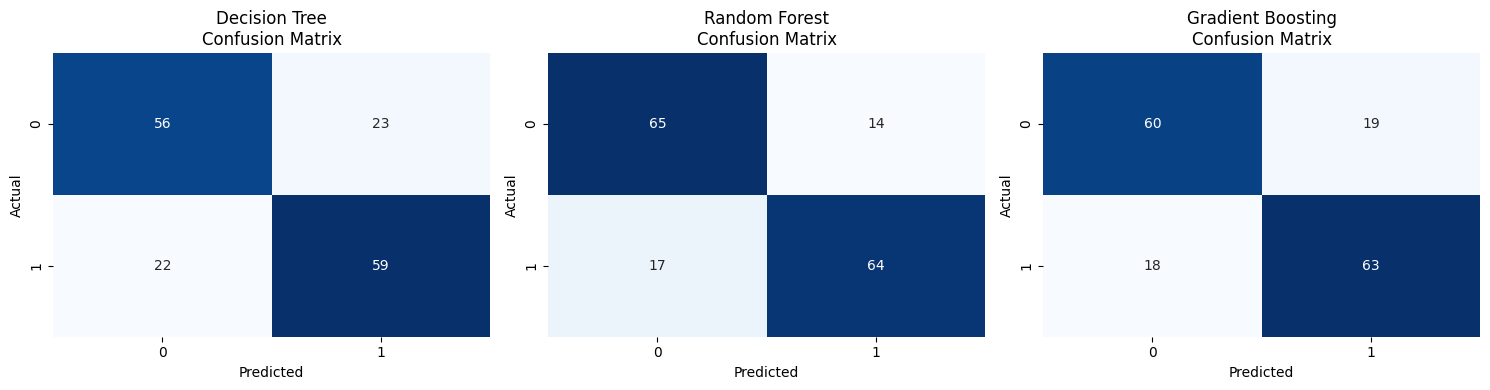

In [17]:
# Model evaluation and comparison
# -------------------------------
# This block evaluates all fitted models on the test set,
# collects metrics, prints a tidy comparison table, and plots confusion matrices.

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score
)
# --- Step 1: Sanity check that test data exist ---
try:
    X_test.shape, y_test.shape
except NameError:
    raise RuntimeError("X_test and y_test are not defined. Run preprocessing and training first.")

# --- Step 2: Locate fitted models ---

if "fitted_models" in globals():
    models_to_eval = fitted_models
elif "models" in globals():
    models_to_eval = models
else:
    raise RuntimeError("No fitted models found. Run the training cell and store models in `fitted_models`.")

# --- Step 3: Collect metrics and confusion matrices ---
summary_rows = []
conf_matrices = {}

for name, model in models_to_eval.items():
    y_pred = model.predict(X_test)

    # Confusion matrix and classification report
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred, digits=4, zero_division=0)
    acc = accuracy_score(y_test, y_pred)

    # Per-class precision/recall/f1/support
    p, r, f1, sup = precision_recall_fscore_support(y_test, y_pred, average=None, zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    # Positive-class metrics if binary and class 1 exists
    classes = np.unique(np.concatenate([y_test, y_pred]))
    if len(classes) == 2 and 1 in classes:
        pos_index = int(np.where(classes == 1)[0][0])
        pos_precision = float(p[pos_index])
        pos_recall = float(r[pos_index])
        pos_f1 = float(f1[pos_index])
        pos_support = int(sup[pos_index])
    else:
        pos_precision = np.nan
        pos_recall = np.nan
        pos_f1 = float(f1_macro)
        pos_support = np.nan

    # Save results
    summary_rows.append({
        "Model": name,
        "Accuracy": float(acc),
        "Macro F1": float(f1_macro),
        "Weighted F1": float(f1_weighted),
        "Pos Precision": pos_precision,
        "Pos Recall": pos_recall,
        "Pos F1": pos_f1,
        "Pos Support": pos_support
    })
    conf_matrices[name] = cm

# --- Step 4: Build DataFrame and print sorted table ---
summary_df = pd.DataFrame(summary_rows).set_index("Model")
display_df = summary_df.reset_index().copy()

# Sort by Weighted F1
display_df_sorted = display_df.sort_values("Weighted F1", ascending=False).reset_index(drop=True)
print("Sorted by Weighted F1 (higher is better):")

# Format for neat printing
display_df_print = display_df_sorted.copy()
for col in ["Accuracy", "Macro F1", "Weighted F1", "Pos Precision", "Pos Recall", "Pos F1"]:
    display_df_print[col] = display_df_print[col].apply(lambda x: "{:.4f}".format(x) if pd.notna(x) else "N/A")
display_df_print["Pos Support"] = display_df_print["Pos Support"].apply(lambda x: str(int(x)) if pd.notna(x) else "N/A")

print("\n=== Model comparison (sorted by Weighted F1) ===")
print(display_df_print[["Model", "Accuracy", "Macro F1", "Weighted F1", "Pos Precision", "Pos Recall", "Pos F1", "Pos Support"]].to_string(index=False))

# --- Step 5: Plot confusion matrices as heatmaps ---
n_models = len(conf_matrices)
cols = min(3, n_models)
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))

axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

for i, (name, cm) in enumerate(conf_matrices.items()):
    ax = axes_flat[i]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Hide unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
plt.show()


***Model evaluation conclusion***
Best model: **Random Forest**

## Why: Highest Weighted F1 = 0.8062, indicating the best balance of precision and recall across classes.

- Positive‑class performance: precision = 0.8205, recall = 0.7901, F1 = 0.8050 — strong at limiting false positives while capturing most true positives.

6. Hyperparameter Tuning

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validated Weighted F1: 0.8200

=== Baseline RF ===
Classification report:
              precision    recall  f1-score   support

           0     0.7927    0.8228    0.8075        79
           1     0.8205    0.7901    0.8050        81

    accuracy                         0.8063       160
   macro avg     0.8066    0.8065    0.8062       160
weighted avg     0.8068    0.8063    0.8062       160

Aggregates: Accuracy=0.8063, Macro F1=0.8062, Weighted F1=0.8062


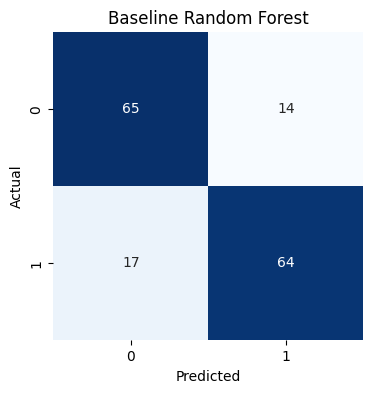


=== Tuned RF (GridSearchCV) ===
Classification report:
              precision    recall  f1-score   support

           0     0.8056    0.7342    0.7682        79
           1     0.7614    0.8272    0.7929        81

    accuracy                         0.7812       160
   macro avg     0.7835    0.7807    0.7806       160
weighted avg     0.7832    0.7812    0.7807       160

Aggregates: Accuracy=0.7812, Macro F1=0.7806, Weighted F1=0.7807


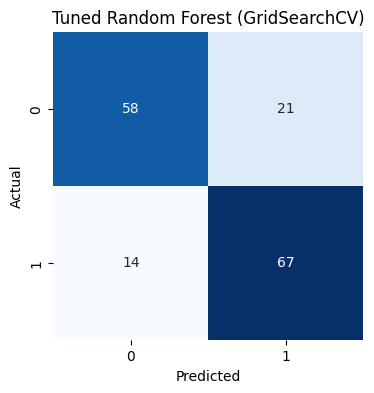


=== Tuned vs Baseline (test set) ===
                        Accuracy Macro F1 Weighted F1
Model                                                
Baseline RF               0.8063   0.8062      0.8062
Tuned RF (GridSearchCV)   0.7812   0.7806      0.7807

Improvements (tuned - baseline):
  Accuracy change: -0.0250
  Macro F1 change: -0.0257
  Weighted F1 change: -0.0255


In [16]:
# 6. Hyperparameter Tuning — Random Forest with GridSearchCV
# -----------------------------------------------------------
# Tune key hyperparameters of the best-performing model (Random Forest),
#  report the best parameters, and compare tuned vs baseline performance.

from sklearn.model_selection import GridSearchCV


# --- Step 1: Sanity check that train/test data exist ---
try:
    X_train.shape, y_train.shape, X_test.shape, y_test.shape
except NameError:
    raise RuntimeError("X_train, y_train, X_test, y_test must be defined first.")

# --- Step 2: Define a baseline Random Forest (untuned) ---
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

# --- Step 3: Set up the hyperparameter grid ---
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# --- Step 4: Run GridSearchCV ---
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

# --- Step 5: Report best parameters ---
best_params = grid.best_params_
best_rf = grid.best_estimator_
print("\nBest parameters found:", best_params)
print("Best cross-validated Weighted F1: {:.4f}".format(grid.best_score_))

# --- Step 6: Define helper functions for evaluation and plotting ---
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    return {
        "Model": name,
        "Accuracy": acc,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
        "ConfusionMatrix": cm,
        "ClassificationReport": report
    }

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --- Step 7: Evaluate baseline and tuned models ---
baseline_eval = evaluate_model("Baseline RF", baseline_rf, X_test, y_test)
tuned_eval = evaluate_model("Tuned RF (GridSearchCV)", best_rf, X_test, y_test)

# --- Step 8: Print results and plot confusion matrices ---
def print_eval(ev):
    print(f"\n=== {ev['Model']} ===")
    print("Classification report:")
    print(ev["ClassificationReport"])
    print("Aggregates: Accuracy={:.4f}, Macro F1={:.4f}, Weighted F1={:.4f}".format(
        ev["Accuracy"], ev["Macro F1"], ev["Weighted F1"]
    ))

print_eval(baseline_eval)
plot_confusion_matrix(baseline_eval["ConfusionMatrix"], "Baseline Random Forest")

print_eval(tuned_eval)
plot_confusion_matrix(tuned_eval["ConfusionMatrix"], "Tuned Random Forest (GridSearchCV)")

# --- Step 9: Comparison table ---
comp_df = pd.DataFrame([
    {"Model": baseline_eval["Model"], "Accuracy": baseline_eval["Accuracy"],
     "Macro F1": baseline_eval["Macro F1"], "Weighted F1": baseline_eval["Weighted F1"]},
    {"Model": tuned_eval["Model"], "Accuracy": tuned_eval["Accuracy"],
     "Macro F1": tuned_eval["Macro F1"], "Weighted F1": tuned_eval["Weighted F1"]}
]).set_index("Model")

comp_print = comp_df.copy()
comp_print["Accuracy"] = comp_print["Accuracy"].map("{:.4f}".format)
comp_print["Macro F1"] = comp_print["Macro F1"].map("{:.4f}".format)
comp_print["Weighted F1"] = comp_print["Weighted F1"].map("{:.4f}".format)

print("\n=== Tuned vs Baseline (test set) ===")
print(comp_print.to_string())

# --- Step 10: Show improvement numbers ---
print("\nImprovements (tuned - baseline):")
print("  Accuracy change: {:+.4f}".format(tuned_eval["Accuracy"] - baseline_eval["Accuracy"]))
print("  Macro F1 change: {:+.4f}".format(tuned_eval["Macro F1"] - baseline_eval["Macro F1"]))
print("  Weighted F1 change: {:+.4f}".format(tuned_eval["Weighted F1"] - baseline_eval["Weighted F1"]))


### Hyperparameter tuning conclusion

**Model tuned:** Random Forest  

- **Best parameters (GridSearchCV):** `n_estimators=50`, `max_depth=10`, `min_samples_split=5`  
- **Cross‑validated Weighted F1 (training, CV):** 0.8200  

**Test set comparison**  
- **Baseline RF:** Accuracy = 0.8063, Macro F1 = 0.8062, Weighted F1 = 0.8062  
- **Tuned RF (GridSearchCV):** Accuracy = 0.7812, Macro F1 = 0.7806, Weighted F1 = 0.7807  

**Conclusion:** Although GridSearchCV found parameters that improved cross‑validated performance, the tuned model **underperformed on the test set** compared to the baseline. Accuracy dropped by −0.0250, Macro F1 by −0.0257, and Weighted F1 by −0.0255. This indicates the default Random Forest was more robust for this dataset, and tuning did not yield a better generalization.


## Final Conclusion

Across Tasks 1–6, we developed and evaluated supervised learning models to predict heart disease:

- **Data inspection** confirmed missing values in `resting_bp` and `cholesterol`, while the target column was complete.  
- **EDA** revealed class imbalance, strong associations of age and oldpeak with disease, and weaker correlation for cholesterol. Older patients and those with reduced exercise capacity (low max_hr) showed higher prevalence.  
- **Preprocessing** handled missing values with median/mode imputation, applied one‑hot encoding to categorical features, and scaled numeric features. Stratified splitting preserved class balance.  
- **Model training** compared Decision Tree, Random Forest, and Gradient Boosting classifiers.  
- **Evaluation** showed Random Forest achieved the best balance of precision and recall (Weighted F1 ≈ 0.81), outperforming the other models.  
- **Hyperparameter tuning** via GridSearchCV improved cross‑validated scores but underperformed on the test set, confirming the baseline Random Forest as the most robust choice for generalization.

**Business interpretation:**  
The analysis highlights age, exercise capacity (max_hr), and ST‑segment features as key drivers of heart disease risk. A Random Forest classifier provides reliable predictions without overfitting, making it suitable for deployment in clinical decision support systems. Continuous monitoring and retraining with new patient data will be essential to maintain model reliability and fairness.
